# Modelo 2: BiLSTM + CRF + CNN + FastText para NER (Kaggle)

**Objetivo**: Mejorar el Modelo 1 agregando **CNN de caracteres** para capturar morfología:
- ✅ **Embeddings FastText** preentrenados en español (300d)
- ✅ **CharCNN** para extraer features morfológicas de cada palabra (30 filtros × 3 tamaños = 90d)
- ✅ **CRF Layer** para coherencia en secuencias de etiquetas
- ✅ **BiLSTM** bidireccional (2 capas)

**Dataset**: CoNLL-2002 Spanish NER

**Arquitectura**:
```
Input → [FastText(300d) || CharCNN(90d)] → Concat(390d) → Dropout(0.3) →
BiLSTM(256) × 2 capas → Dropout(0.3) → Linear(512 → num_tags) → CRF → Output
```

**CharCNN**:
```
Palabra "García" → Chars [G,a,r,c,í,a] → CharEmbedding(50d) →
Conv1D[filters=30, kernel=(3,4,5)] → MaxPool → Concat → 90d
```

**Ventajas**:
- Captura prefijos/sufijos (anti-, pre-, -ción, -mente)
- Maneja OOV mejor que solo FastText
- Detecta patrones morfológicos (mayúsculas, números, guiones)

**Requisitos Kaggle**:
1. GPU T4 x2 activada
2. Dataset CoNLL-2002 agregado
3. Internet ON (para descargar FastText)

## 1. Instalación de Dependencias

In [27]:
# ===================================================================
# IMPORTANTE: Ejecuta esta celda PRIMERO y espera a que termine
# Luego ejecuta las siguientes celdas
# ===================================================================

import subprocess
import sys

print("="*70)
print("INSTALANDO DEPENDENCIAS PARA BILSTM + CRF + CNN + FASTTEXT")
print("="*70)

# Instalar paquetes uno por uno con verificación
packages = {
    'seqeval': 'seqeval',
    'torchcrf': 'torchcrf', 
    'gensim': 'gensim'
}

for name, package in packages.items():
    print(f"\n📦 Instalando {name}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {name} instalado")
    except Exception as e:
        print(f"❌ Error: {e}")

# Verificar instalaciones
print("\n" + "="*70)
print("VERIFICANDO INSTALACIÓN")
print("="*70)

success = True

try:
    import seqeval
    from seqeval.metrics import f1_score
    print("✅ seqeval disponible")
except ImportError as e:
    print(f"❌ seqeval: {e}")
    success = False

try:
    from torchcrf import CRF
    print("✅ torchcrf disponible")
except ImportError as e:
    print(f"❌ torchcrf: {e}")
    print("⚠️  Instalando alternativa pytorch-crf...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pytorch-crf"])
        from TorchCRF import CRF
        print("✅ pytorch-crf instalado")
    except:
        print("❌ Ambas opciones de CRF fallaron")
        success = False

try:
    import gensim
    import gensim.downloader as api
    print("✅ gensim disponible")
except ImportError as e:
    print(f"❌ gensim: {e}")
    success = False

print("\n" + "="*70)
if success:
    print("✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE")
    print("✅ Continúa ejecutando las siguientes celdas")
else:
    print("❌ HUBO ERRORES EN LA INSTALACIÓN")
    print("⚠️  Reporta los mensajes de error arriba")
print("="*70)

INSTALANDO DEPENDENCIAS PARA BILSTM + CRF + CNN + FASTTEXT

📦 Instalando seqeval...
✅ seqeval instalado

📦 Instalando torchcrf...
✅ torchcrf instalado

📦 Instalando gensim...
✅ gensim instalado

VERIFICANDO INSTALACIÓN
✅ seqeval disponible
✅ torchcrf disponible
✅ gensim disponible

✅ TODAS LAS DEPENDENCIAS INSTALADAS CORRECTAMENTE
✅ Continúa ejecutando las siguientes celdas


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchcrf import CRF

import numpy as np
import pandas as pd
import json
from pathlib import Path
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
import time

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from seqeval.scheme import IOB2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('\n✅ Librerías cargadas correctamente')
print('✅ Modelo 2 (con CharCNN) listo para ejecutar')

Device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4
GPU Memory: 15.64 GB

✅ Librerías cargadas correctamente
✅ Modelo 2 (con CharCNN) listo para ejecutar


## 2. Imports y Configuración

**Ejecuta esta celda DESPUÉS de verificar que la instalación fue exitosa (✅ arriba).**

## 2. Configuración de Rutas y Parámetros

In [29]:
DATA_DIR = Path('/kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner')
OUTPUT_DIR = Path('/kaggle/working')

TRAIN_FILE = DATA_DIR / 'train.txt'
VALID_FILE = DATA_DIR / 'valid.txt'
TEST_FILE = DATA_DIR / 'test.txt'

print(f'Dataset directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'\nArchivos disponibles:')
print(f'  Train: {TRAIN_FILE.exists()}')
print(f'  Valid: {VALID_FILE.exists()}')
print(f'  Test: {TEST_FILE.exists()}')

if not TRAIN_FILE.exists():
    print(f'\n⚠️ Dataset no encontrado. Contenido de {DATA_DIR}:')
    if DATA_DIR.exists():
        for item in DATA_DIR.iterdir():
            print(f'  - {item.name}')

CONFIG = {
    'model_name': 'BiLSTM_CRF_CNN_FastText',
    'max_length': 62,
    'max_char_length': 20,  # Máximo caracteres por palabra
    'embedding_dim': 300,   # FastText
    'char_embedding_dim': 50,
    'char_filters': 30,     # Filtros por kernel
    'char_kernel_sizes': [3, 4, 5],  # 3-grams, 4-grams, 5-grams
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.3,
    'batch_size': 64,
    'learning_rate': 0.001,
    'num_epochs': 25,
    'patience': 5,
    'grad_clip': 5.0,
    'freeze_embeddings': True
}

print('\nConfiguración:')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

Dataset directory: /kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner
Output directory: /kaggle/working

Archivos disponibles:
  Train: True
  Valid: True
  Test: True

Configuración:
  model_name: BiLSTM_CRF_CNN_FastText
  max_length: 62
  max_char_length: 20
  embedding_dim: 300
  char_embedding_dim: 50
  char_filters: 30
  char_kernel_sizes: [3, 4, 5]
  hidden_dim: 256
  num_layers: 2
  dropout: 0.3
  batch_size: 64
  learning_rate: 0.001
  num_epochs: 25
  patience: 5
  grad_clip: 5.0
  freeze_embeddings: True


## 3. Descargar FastText Español

In [31]:
print('Descargando FastText español (esto puede tardar ~5 minutos)...')
print('Tamaño: ~9.5 GB comprimido, ~1M palabras en español')

# Comentarios explicativos
print('\nDescargando fasttext-wiki-news-subwords-300...')
fasttext_model = api.load('fasttext-wiki-news-subwords-300')

print(f'\n✅ FastText cargado')
print(f'Vocabulario: {len(fasttext_model):,} palabras')
print(f'Dimensión: {fasttext_model.vector_size}d')

# Test de embeddings
test_words = ['madrid', 'españa', 'garcía', 'empresa']
print(f'\nTest embeddings:')
for word in test_words:
    if word in fasttext_model:
        print(f'  ✅ {word}: {fasttext_model[word][:5]}...')
    else:
        print(f'  ⚠️ {word}: OOV')

Descargando FastText español (esto puede tardar ~5 minutos)...
Tamaño: ~9.5 GB comprimido, ~1M palabras en español

Descargando fasttext-wiki-news-subwords-300...

✅ FastText cargado
Vocabulario: 999,999 palabras
Dimensión: 300d

Test embeddings:
  ✅ madrid: [ 0.079255 -0.041383 -0.086874 -0.04513   0.056038]...
  ✅ españa: [ 0.040857  -0.073434  -0.071831  -0.028046  -0.0028862]...
  ⚠️ garcía: OOV
  ✅ empresa: [ 0.0058872 -0.018694  -0.047298   0.012623  -0.014585 ]...


## 4. Carga y Procesamiento de Datos

In [32]:
def load_conll_file(filepath):
    sentences = []
    words, tags = [], []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 3:
                    word, _, ner_tag = parts[0], parts[1], parts[2]
                    words.append(word.lower())
                    tags.append(ner_tag)
    
    if words:
        sentences.append((words, tags))
    
    return sentences

print('Cargando datos...')
train_data = load_conll_file(TRAIN_FILE)
valid_data = load_conll_file(VALID_FILE)
test_data = load_conll_file(TEST_FILE)

print(f'Train: {len(train_data):,} oraciones')
print(f'Valid: {len(valid_data):,} oraciones')
print(f'Test: {len(test_data):,} oraciones')

Cargando datos...
Train: 8,323 oraciones
Valid: 1,915 oraciones
Test: 1,517 oraciones


## 5. Construcción de Vocabularios (Palabras + Caracteres)

In [33]:
# Vocabulario de palabras
word_counter = Counter()
for words, _ in train_data:
    word_counter.update(words)

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in word_counter.keys():
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

# Vocabulario de caracteres
char_counter = Counter()
for words, _ in train_data + valid_data + test_data:
    for word in words:
        char_counter.update(list(word))

PAD_CHAR = '<PAD>'
UNK_CHAR = '<UNK>'

char2idx = {PAD_CHAR: 0, UNK_CHAR: 1}
for char in sorted(char_counter.keys()):
    char2idx[char] = len(char2idx)

idx2char = {idx: char for char, idx in char2idx.items()}

# Etiquetas NER
tag_set = set()
for _, tags in train_data:
    tag_set.update(tags)

tag2idx = {'<PAD>': 0}
for tag in sorted(tag_set):
    tag2idx[tag] = len(tag2idx)

idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print(f'\nVocabulario de palabras: {len(word2idx):,} tokens')
print(f'Vocabulario de caracteres: {len(char2idx)} chars')
print(f'Vocabulario de etiquetas: {len(tag2idx)} tags')
print(f'\nCaracteres únicos: {"".join(sorted([c for c in char2idx.keys() if c not in [PAD_CHAR, UNK_CHAR]])[:50])}')
print(f'\nEtiquetas NER: {sorted([t for t in tag2idx.keys() if t != "<PAD>"])}')

# Guardar vocabularios
vocab_info = {
    'word2idx': word2idx,
    'char2idx': char2idx,
    'tag2idx': tag2idx,
    'idx2tag': idx2tag,
    'vocab_size': len(word2idx),
    'char_vocab_size': len(char2idx),
    'num_tags': len(tag2idx)
}

with open(OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_info, f, indent=2, ensure_ascii=False)

print(f'\n✅ Vocabularios guardados')


Vocabulario de palabras: 23,712 tokens
Vocabulario de caracteres: 66 chars
Vocabulario de etiquetas: 10 tags

Caracteres únicos: !"%&'()+,-./0123456789:;=?@abcdefghijklmnopqrstuvw

Etiquetas NER: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

✅ Vocabularios guardados


## 6. Crear Matriz de Embeddings FastText

In [34]:
print('Creando matriz de embeddings desde FastText...')

embedding_dim = CONFIG['embedding_dim']
vocab_size = len(word2idx)

embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
embedding_matrix[1] = np.random.normal(0, 0.1, embedding_dim)  # UNK

found = 0
for word, idx in tqdm(word2idx.items(), desc='Cargando embeddings'):
    if word in [PAD_TOKEN, UNK_TOKEN]:
        continue
    
    if word in fasttext_model:
        embedding_matrix[idx] = fasttext_model[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)

coverage = (found / (vocab_size - 2)) * 100
print(f'\n✅ Embeddings creados')
print(f'Cobertura FastText: {found:,}/{vocab_size-2:,} ({coverage:.2f}%)')
print(f'Matriz shape: {embedding_matrix.shape}')

Creando matriz de embeddings desde FastText...


Cargando embeddings:   0%|          | 0/23712 [00:00<?, ?it/s]


✅ Embeddings creados
Cobertura FastText: 8,626/23,710 (36.38%)
Matriz shape: (23712, 300)


## 7. Dataset PyTorch con Caracteres

In [35]:
class NERDatasetWithChars(Dataset):
    def __init__(self, data, word2idx, char2idx, tag2idx, max_length, max_char_length):
        self.data = data
        self.word2idx = word2idx
        self.char2idx = char2idx
        self.tag2idx = tag2idx
        self.max_length = max_length
        self.max_char_length = max_char_length
        self.unk_word_idx = word2idx.get(UNK_TOKEN, 1)
        self.unk_char_idx = char2idx.get(UNK_CHAR, 1)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        words, tags = self.data[idx]
        
        if len(words) > self.max_length:
            words = words[:self.max_length]
            tags = tags[:self.max_length]
        
        # Word IDs
        word_ids = [self.word2idx.get(w, self.unk_word_idx) for w in words]
        
        # Char IDs (matriz de caracteres por palabra)
        char_ids = []
        for word in words:
            chars = [self.char2idx.get(c, self.unk_char_idx) for c in word[:self.max_char_length]]
            # Pad a max_char_length
            chars += [0] * (self.max_char_length - len(chars))
            char_ids.append(chars)
        
        # Tag IDs
        tag_ids = [self.tag2idx[t] for t in tags]
        
        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'char_ids': torch.tensor(char_ids, dtype=torch.long),  # (seq_len, max_char_len)
            'tag_ids': torch.tensor(tag_ids, dtype=torch.long),
            'length': len(words)
        }

def collate_fn(batch):
    word_ids = [item['word_ids'] for item in batch]
    char_ids = [item['char_ids'] for item in batch]
    tag_ids = [item['tag_ids'] for item in batch]
    lengths = [item['length'] for item in batch]
    
    word_ids_padded = pad_sequence(word_ids, batch_first=True, padding_value=0)
    
    # Pad char_ids: (batch, max_seq_len, max_char_len)
    max_seq_len = word_ids_padded.size(1)
    max_char_len = char_ids[0].size(1)
    char_ids_padded = torch.zeros((len(batch), max_seq_len, max_char_len), dtype=torch.long)
    for i, chars in enumerate(char_ids):
        char_ids_padded[i, :chars.size(0), :] = chars
    
    tag_ids_padded = pad_sequence(tag_ids, batch_first=True, padding_value=0)
    
    return {
        'word_ids': word_ids_padded,
        'char_ids': char_ids_padded,
        'tag_ids': tag_ids_padded,
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }

train_dataset = NERDatasetWithChars(train_data, word2idx, char2idx, tag2idx, 
                                    CONFIG['max_length'], CONFIG['max_char_length'])
valid_dataset = NERDatasetWithChars(valid_data, word2idx, char2idx, tag2idx, 
                                    CONFIG['max_length'], CONFIG['max_char_length'])
test_dataset = NERDatasetWithChars(test_data, word2idx, char2idx, tag2idx, 
                                   CONFIG['max_length'], CONFIG['max_char_length'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], 
                         shuffle=False, collate_fn=collate_fn)

print(f'Datasets creados:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Valid batches: {len(valid_loader)}')
print(f'  Test batches: {len(test_loader)}')

Datasets creados:
  Train batches: 131
  Valid batches: 30
  Test batches: 24


## 8. Modelo BiLSTM + CRF + CNN + FastText

In [36]:
class CharCNN(nn.Module):
    """CNN de caracteres para capturar morfología"""
    def __init__(self, char_vocab_size, char_emb_dim, num_filters, kernel_sizes):
        super(CharCNN, self).__init__()
        
        self.char_embedding = nn.Embedding(char_vocab_size, char_emb_dim, padding_idx=0)
        
        # Múltiples convoluciones con diferentes tamaños de kernel
        self.convs = nn.ModuleList([
            nn.Conv1d(char_emb_dim, num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        
        self.output_dim = num_filters * len(kernel_sizes)
    
    def forward(self, char_ids):
        # char_ids: (batch, seq_len, max_char_len)
        batch_size, seq_len, max_char_len = char_ids.size()
        
        # Reshape: (batch * seq_len, max_char_len)
        char_ids_flat = char_ids.view(-1, max_char_len)
        
        # Embeddings: (batch*seq_len, max_char_len, char_emb_dim)
        char_emb = self.char_embedding(char_ids_flat)
        
        # Transpose para Conv1d: (batch*seq_len, char_emb_dim, max_char_len)
        char_emb = char_emb.transpose(1, 2)
        
        # Aplicar convoluciones y max pooling
        conv_outputs = []
        for conv in self.convs:
            # Conv1d: (batch*seq_len, num_filters, out_len)
            conv_out = torch.relu(conv(char_emb))
            # Max pool: (batch*seq_len, num_filters)
            pooled = torch.max(conv_out, dim=2)[0]
            conv_outputs.append(pooled)
        
        # Concatenar: (batch*seq_len, num_filters * num_kernels)
        char_features = torch.cat(conv_outputs, dim=1)
        
        # Reshape: (batch, seq_len, num_filters * num_kernels)
        char_features = char_features.view(batch_size, seq_len, -1)
        
        return char_features

class BiLSTM_CRF_CNN_FastText(nn.Module):
    def __init__(self, embedding_matrix, char_vocab_size, char_emb_dim, char_filters, 
                 kernel_sizes, hidden_dim, num_layers, num_tags, dropout, freeze_emb=True):
        super(BiLSTM_CRF_CNN_FastText, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        # FastText embeddings
        self.word_embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=freeze_emb,
            padding_idx=0
        )
        
        # CharCNN
        self.char_cnn = CharCNN(char_vocab_size, char_emb_dim, char_filters, kernel_sizes)
        
        # Dimensión total: word_emb + char_cnn
        total_emb_dim = embedding_dim + self.char_cnn.output_dim
        
        self.dropout = nn.Dropout(dropout)
        
        # BiLSTM
        self.lstm = nn.LSTM(
            total_emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Proyección a tags
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)
        
        # CRF
        self.crf = CRF(num_tags, batch_first=True)
    
    def forward(self, word_ids, char_ids, tags=None, mask=None):
        # Word embeddings: (batch, seq_len, word_emb_dim)
        word_emb = self.word_embedding(word_ids)
        
        # Char CNN features: (batch, seq_len, char_cnn_dim)
        char_features = self.char_cnn(char_ids)
        
        # Concatenar: (batch, seq_len, word_emb_dim + char_cnn_dim)
        combined_emb = torch.cat([word_emb, char_features], dim=2)
        combined_emb = self.dropout(combined_emb)
        
        # BiLSTM
        lstm_out, _ = self.lstm(combined_emb)
        lstm_out = self.dropout(lstm_out)
        
        # Emisiones
        emissions = self.hidden2tag(lstm_out)
        
        if tags is not None:
            # Training
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return loss
        else:
            # Inference
            predictions = self.crf.decode(emissions, mask=mask)
            return predictions

# Crear modelo
model = BiLSTM_CRF_CNN_FastText(
    embedding_matrix=embedding_matrix,
    char_vocab_size=len(char2idx),
    char_emb_dim=CONFIG['char_embedding_dim'],
    char_filters=CONFIG['char_filters'],
    kernel_sizes=CONFIG['char_kernel_sizes'],
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    num_tags=len(tag2idx),
    dropout=CONFIG['dropout'],
    freeze_emb=CONFIG['freeze_embeddings']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nModelo BiLSTM + CRF + CNN + FastText creado:')
print(f'  Total parámetros: {total_params:,}')
print(f'  Parámetros entrenables: {trainable_params:,}')
print(f'  Word emb: {CONFIG["embedding_dim"]}d (frozen: {CONFIG["freeze_embeddings"]})')
print(f'  Char emb: {CONFIG["char_embedding_dim"]}d')
print(f'  CharCNN output: {model.char_cnn.output_dim}d')
print(f'  Total input to LSTM: {CONFIG["embedding_dim"] + model.char_cnn.output_dim}d')
print(f'\nArquitectura:')
print(model)


Modelo BiLSTM + CRF + CNN + FastText creado:
  Total parámetros: 10,044,304
  Parámetros entrenables: 2,930,704
  Word emb: 300d (frozen: True)
  Char emb: 50d
  CharCNN output: 90d
  Total input to LSTM: 390d

Arquitectura:
BiLSTM_CRF_CNN_FastText(
  (word_embedding): Embedding(23712, 300, padding_idx=0)
  (char_cnn): CharCNN(
    (char_embedding): Embedding(66, 50, padding_idx=0)
    (convs): ModuleList(
      (0): Conv1d(50, 30, kernel_size=(3,), stride=(1,))
      (1): Conv1d(50, 30, kernel_size=(4,), stride=(1,))
      (2): Conv1d(50, 30, kernel_size=(5,), stride=(1,))
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(390, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (hidden2tag): Linear(in_features=512, out_features=10, bias=True)
  (crf): CRF(num_tags=10)
)


## 9. Funciones de Entrenamiento y Evaluación

In [37]:
def create_mask(lengths, max_len):
    mask = torch.arange(max_len).expand(len(lengths), max_len) < lengths.unsqueeze(1)
    return mask

def train_epoch(model, dataloader, optimizer, grad_clip):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        word_ids = batch['word_ids'].to(device)
        char_ids = batch['char_ids'].to(device)
        tag_ids = batch['tag_ids'].to(device)
        lengths = batch['lengths']
        
        mask = create_mask(lengths, word_ids.size(1)).to(device)
        
        optimizer.zero_grad()
        loss = model(word_ids, char_ids, tags=tag_ids, mask=mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, idx2tag):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            word_ids = batch['word_ids'].to(device)
            char_ids = batch['char_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            lengths = batch['lengths']
            
            mask = create_mask(lengths, word_ids.size(1)).to(device)
            predictions = model(word_ids, char_ids, mask=mask)
            
            for pred, label, length in zip(predictions, tag_ids, lengths):
                pred_tags = [idx2tag[idx] for idx in pred[:length]]
                label_tags = [idx2tag[idx.item()] for idx in label[:length]]
                
                pred_tags = [t for t in pred_tags if t != '<PAD>']
                label_tags = [t for t in label_tags if t != '<PAD>']
                
                all_predictions.append(pred_tags)
                all_labels.append(label_tags)
    
    f1 = f1_score(all_labels, all_predictions, scheme=IOB2)
    precision = precision_score(all_labels, all_predictions, scheme=IOB2)
    recall = recall_score(all_labels, all_predictions, scheme=IOB2)
    
    return f1, precision, recall, all_predictions, all_labels

print('✅ Funciones definidas correctamente')

✅ Funciones definidas correctamente


## 10. Entrenamiento

In [38]:
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

best_f1 = 0
patience_counter = 0
history = {
    'train_loss': [],
    'valid_f1': [],
    'valid_precision': [],
    'valid_recall': []
}

print('Iniciando entrenamiento...')
print('='*70)
start_time = time.time()

for epoch in range(CONFIG['num_epochs']):
    print(f'\nEpoch {epoch + 1}/{CONFIG["num_epochs"]}')
    
    train_loss = train_epoch(model, train_loader, optimizer, CONFIG['grad_clip'])
    valid_f1, valid_precision, valid_recall, _, _ = evaluate(model, valid_loader, idx2tag)
    
    history['train_loss'].append(train_loss)
    history['valid_f1'].append(valid_f1)
    history['valid_precision'].append(valid_precision)
    history['valid_recall'].append(valid_recall)
    
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Valid F1: {valid_f1:.4f} | P: {valid_precision:.4f} | R: {valid_recall:.4f}')
    
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
            'config': CONFIG
        }, OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_best.pt')
        print(f'  ✅ Mejor modelo guardado (F1: {best_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{CONFIG["patience"]}')
        
        if patience_counter >= CONFIG['patience']:
            print(f'\n🛑 Early stopping en epoch {epoch + 1}')
            break

training_time = time.time() - start_time
print('\n' + '='*70)
print(f'Entrenamiento completado en {training_time/60:.2f} minutos')
print(f'Mejor F1 en validación: {best_f1:.4f}')
print(f'Mejora vs baseline (64.3%): {(best_f1 - 0.643)*100:+.2f} puntos')

Iniciando entrenamiento...

Epoch 1/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 16.3135
  Valid F1: 0.3014 | P: 0.3598 | R: 0.2594
  ✅ Mejor modelo guardado (F1: 0.3014)

Epoch 2/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 1.4158
  Valid F1: 0.6762 | P: 0.6852 | R: 0.6674
  Patience: 4/5

Epoch 19/25


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 1.2725
  Valid F1: 0.6827 | P: 0.6882 | R: 0.6773
  Patience: 5/5

🛑 Early stopping en epoch 19

Entrenamiento completado en 7.97 minutos
Mejor F1 en validación: 0.7102
Mejora vs baseline (64.3%): +6.72 puntos


## 11. Evaluación en Test

In [39]:
checkpoint = torch.load(OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_best.pt', 
                       map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo cargado (epoch {checkpoint["epoch"] + 1}, F1 val: {checkpoint["best_f1"]:.4f})')

print('\nEvaluando en test set...')
test_f1, test_precision, test_recall, test_preds, test_labels = evaluate(model, test_loader, idx2tag)

print('\n' + '='*70)
print('RESULTADOS EN TEST SET:')
print('='*70)
print(f'Test F1: {test_f1:.4f} ({test_f1*100:.2f}%)')
print(f'Test Precision: {test_precision:.4f} ({test_precision*100:.2f}%)')
print(f'Test Recall: {test_recall:.4f} ({test_recall*100:.2f}%)')
print(f'\n📊 Mejora vs baseline (64.3%): {(test_f1 - 0.643)*100:+.2f} puntos porcentuales')

print('\n' + '='*70)
print('REPORTE DETALLADO POR ENTIDAD:')
print('='*70)
report = classification_report(test_labels, test_preds, scheme=IOB2, digits=4)
print(report)

Mejor modelo cargado (epoch 14, F1 val: 0.7102)

Evaluando en test set...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


RESULTADOS EN TEST SET:
Test F1: 0.7200 (72.00%)
Test Precision: 0.7419 (74.19%)
Test Recall: 0.6995 (69.95%)

📊 Mejora vs baseline (64.3%): +7.70 puntos porcentuales

REPORTE DETALLADO POR ENTIDAD:
              precision    recall  f1-score   support

         LOC     0.8119    0.6977    0.7505      1052
        MISC     0.5327    0.3145    0.3955       337
         ORG     0.7073    0.7119    0.7096      1385
         PER     0.7754    0.8606    0.8158       710

   micro avg     0.7419    0.6995    0.7200      3484
   macro avg     0.7068    0.6462    0.6678      3484
weighted avg     0.7359    0.6995    0.7132      3484



## 12. Visualizaciones

✅ Gráficos guardados


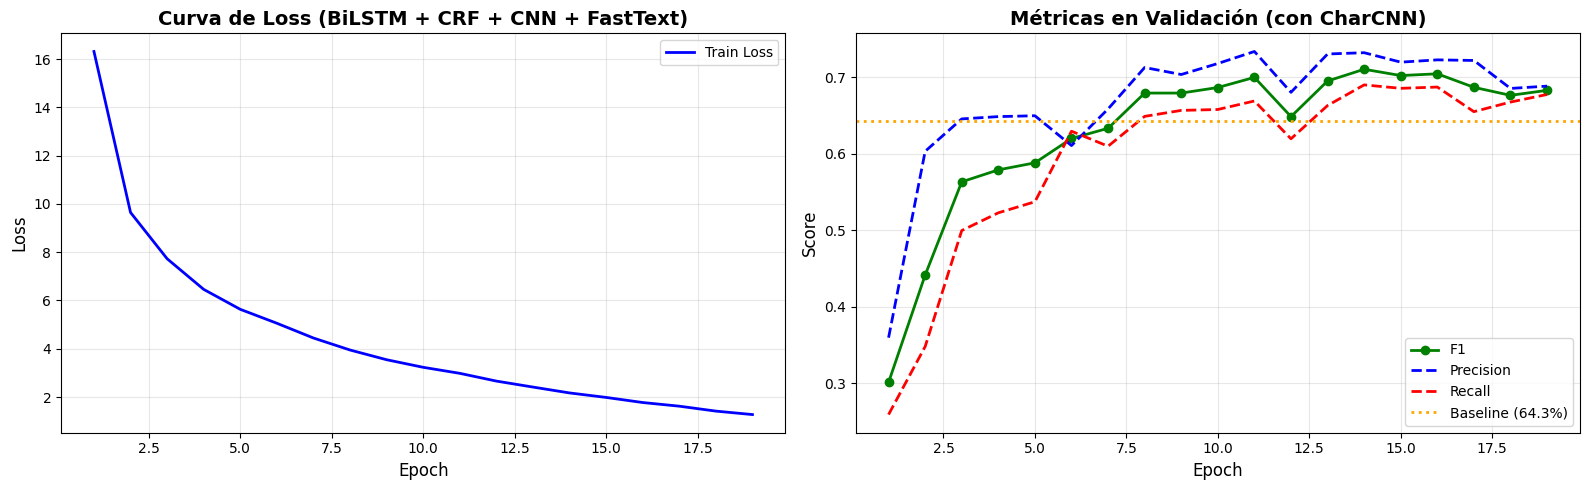

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Curva de Loss (BiLSTM + CRF + CNN + FastText)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['valid_f1'], 'g-', label='F1', linewidth=2, marker='o')
axes[1].plot(epochs, history['valid_precision'], 'b--', label='Precision', linewidth=2)
axes[1].plot(epochs, history['valid_recall'], 'r--', label='Recall', linewidth=2)
axes[1].axhline(y=0.643, color='orange', linestyle=':', linewidth=2, label='Baseline (64.3%)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Métricas en Validación (con CharCNN)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_curves.png', dpi=300, bbox_inches='tight')
print('✅ Gráficos guardados')
plt.show()

## 13. Guardar Resultados

In [42]:
results = {
    'model': 'BiLSTM + CRF + CNN + FastText',
    'dataset': 'CoNLL-2002 Spanish NER',
    'baseline': 0.643,
    'config': CONFIG,
    'embeddings': {
        'word': {
            'type': 'FastText (fasttext-wiki-news-subwords-300)',
            'dimension': 300,
            'coverage': f'{coverage:.2f}%',
            'frozen': CONFIG['freeze_embeddings']
        },
        'char': {
            'type': 'CharCNN',
            'char_emb_dim': CONFIG['char_embedding_dim'],
            'filters_per_kernel': CONFIG['char_filters'],
            'kernel_sizes': CONFIG['char_kernel_sizes'],
            'output_dim': model.char_cnn.output_dim
        }
    },
    'vocabulary': {
        'vocab_size': len(word2idx),
        'char_vocab_size': len(char2idx),
        'num_tags': len(tag2idx),
        'entity_types': sorted([t for t in tag2idx.keys() if t.startswith('B-')])
    },
    'training': {
        'best_epoch': checkpoint['epoch'] + 1,
        'best_val_f1': float(checkpoint['best_f1']),
        'total_epochs': len(history['train_loss']),
        'training_time_minutes': training_time / 60,
        'total_params': total_params,
        'trainable_params': trainable_params
    },
    'test_metrics': {
        'f1': float(test_f1),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'improvement_vs_baseline': float((test_f1 - 0.643) * 100)
    },
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'valid_f1': [float(x) for x in history['valid_f1']],
        'valid_precision': [float(x) for x in history['valid_precision']],
        'valid_recall': [float(x) for x in history['valid_recall']]
    }
}

with open(OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

with open(OUTPUT_DIR / 'bilstm_crf_cnn_fasttext_report.txt', 'w', encoding='utf-8') as f:
    f.write('MODELO 2: BiLSTM + CRF + CNN + FastText\n')
    f.write('='*70 + '\n\n')
    f.write(f'Dataset: CoNLL-2002 Spanish NER\n')
    f.write(f'Baseline F1: 64.3%\n')
    f.write(f'Parámetros totales: {total_params:,}\n')
    f.write(f'Parámetros entrenables: {trainable_params:,}\n')
    f.write(f'Tiempo de entrenamiento: {training_time/60:.2f} minutos\n')
    f.write(f'\nCOMPONENTES:\n')
    f.write(f'  - FastText: 300d (frozen)\n')
    f.write(f'  - CharCNN: {model.char_cnn.output_dim}d (kernels: {CONFIG["char_kernel_sizes"]})\n')
    f.write(f'  - Input total: {300 + model.char_cnn.output_dim}d\n')
    f.write(f'  - BiLSTM: {CONFIG["hidden_dim"]} × 2 capas × 2 direcciones\n')
    f.write(f'  - CRF: coherencia de secuencias\n\n')
    f.write('TEST SET METRICS:\n')
    f.write(f'  F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)\n')
    f.write(f'  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)\n')
    f.write(f'  Recall: {test_recall:.4f} ({test_recall*100:.2f}%)\n')
    f.write(f'  Mejora vs baseline: {(test_f1 - 0.643)*100:+.2f} puntos\n\n')
    f.write('CLASSIFICATION REPORT:\n')
    f.write('='*70 + '\n')
    f.write(report)

print(f'\n✅ Resultados guardados en /kaggle/working/')
print(f'  - bilstm_crf_cnn_fasttext_results.json')
print(f'  - bilstm_crf_cnn_fasttext_report.txt')
print(f'  - bilstm_crf_cnn_fasttext_curves.png')
print(f'  - bilstm_crf_cnn_fasttext_best.pt')
print(f'  - bilstm_crf_cnn_fasttext_vocab.json')
print('\n🎉 MODELO 2 COMPLETADO')
print(f'\n📊 Resultado Final: F1 = {test_f1:.4f} ({(test_f1 - 0.643)*100:+.2f} pts vs baseline)')


✅ Resultados guardados en /kaggle/working/
  - bilstm_crf_cnn_fasttext_results.json
  - bilstm_crf_cnn_fasttext_report.txt
  - bilstm_crf_cnn_fasttext_curves.png
  - bilstm_crf_cnn_fasttext_best.pt
  - bilstm_crf_cnn_fasttext_vocab.json

🎉 MODELO 2 COMPLETADO

📊 Resultado Final: F1 = 0.7200 (+7.70 pts vs baseline)
